In [1]:
import pandas as pd

df  = pd.read_csv("student_data.csv")
print(df.head())

   StudyHours  Attendance  PreviousMarks  Assignments Result
0          57          42             89            6   Fail
1          29          85             83            7   Pass
2          30          49             98            2   Fail
3          44          52             64            2   Fail
4          65          54             49            2   Fail


In [3]:
df.shape
df.info

<bound method DataFrame.info of     StudyHours  Attendance  PreviousMarks  Assignments Result
0           57          42             89            6   Fail
1           29          85             83            7   Pass
2           30          49             98            2   Fail
3           44          52             64            2   Fail
4           65          54             49            2   Fail
..         ...         ...            ...          ...    ...
95          18          92             54           10   Pass
96          18          54             40            1   Fail
97          24          95             51            9   Pass
98          62          47             73            7   Fail
99          31          70             60            5   Pass

[100 rows x 5 columns]>

In [4]:
df.isnull().sum()

StudyHours       0
Attendance       0
PreviousMarks    0
Assignments      0
Result           0
dtype: int64

In [14]:
df["Result"] = (
  (df["StudyHours"] >= 40) &
  (df["Attendance"] >= 60) &
  (df["PreviousMarks"] >= 50)
).astype(int)

In [11]:
df.columns

Index(['StudyHours', 'Attendance', 'PreviousMarks', 'Assignments', 'Result'], dtype='str')

In [7]:
df["Result"] = df["Result"].map({
  "Fail" : 0,
  "Pass" : 1
})

In [16]:
df.head()

,StudyHours,Attendance,PreviousMarks,Assignments,Result
0,57,42,89,6,0
1,29,85,83,7,0
2,30,49,98,2,0
3,44,52,64,2,0
4,65,54,49,2,0


In [17]:
df["Result"].value_counts()

Result
0    72
1    28
Name: count, dtype: int64

In [19]:
import sklearn
print(sklearn.__version__)

1.9.0


In [23]:
X = df[["StudyHours", "Attendance", "PreviousMarks", "Assignments"]]
y = df["Result"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (80, 4)
Testing Features: (20, 4)
Training Labels: (80,)
Testing Labels: (20,)


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test , y_pred_dt)
print("Decision Tree Accuracy:",accuracy_dt)

Decision Tree Accuracy: 1.0


In [30]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[17  0]
 [ 0  3]]


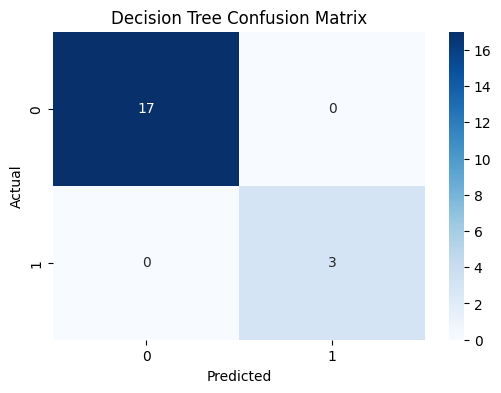

In [ ]:
#Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
  cm,
  annot=True,
  fmt='d',
  cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [33]:
## Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
  n_estimators=100,
  random_state=42
)

rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test , y_pred_rf)
print("Random Forest Accuracy:",accuracy_rf)

Random Forest Accuracy: 1.0


In [34]:
## Random Forest - Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cm)

[[17  0]
 [ 0  3]]


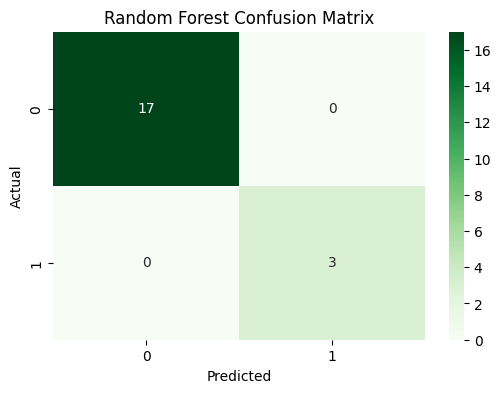

In [36]:
## Random Forest - Confusion Matrix - Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
  cm_rf,
  annot=True,
  fmt='d',
  cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [37]:
#Compare Models

print("Decision Tree Accuracy :", accuracy_dt)
print("Random Forest Accuracy :", accuracy_rf)

Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0


In [38]:
#ROC Curve - Value
from sklearn.metrics import roc_curve,auc

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr,tpr,threshold = roc_curve(y_test,y_prob_rf)
roc_auc = auc(fpr,tpr)
print("AUC score:",roc_auc)

AUC score: 1.0


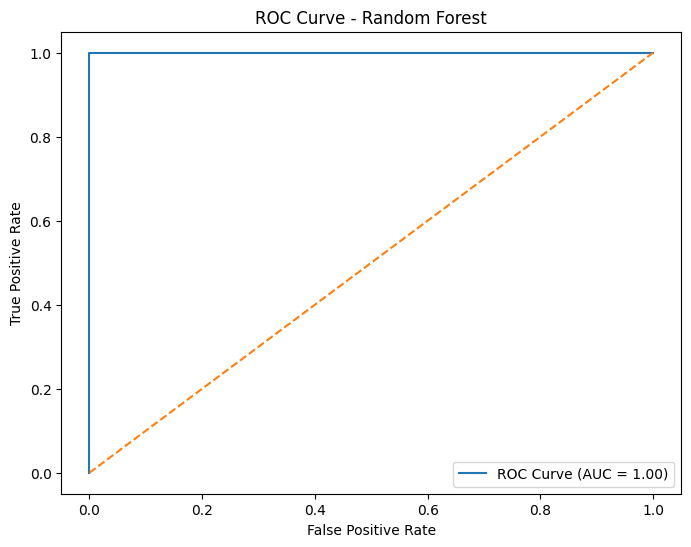

In [39]:
#Plot ROC Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.2f})"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [40]:
print("Decision Tree Accuracy :", accuracy_dt)
print("Random Forest Accuracy :", accuracy_rf)

Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0
